In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

TICKER       = "^BSESN"
START_DATE   = "2023-01-01"
END_DATE     = "2026-01-01"
RISK_FREE    = 0.0
TRADING_DAYS = 252
SHORT_WINDOW = 15
LONG_WINDOW  = 75

In [ ]:
raw = yf.download(TICKER, start=START_DATE, end=END_DATE,progress=False)
df = pd.DataFrame()
df['close'] = raw['Close']
df.dropna(inplace=True) # We are removing those rows in which values are missing

In [ ]:
df['log_returns'] = np.log(df['close'] / df['close'].shift(1))
df.dropna(inplace=True)

print(f"Loaded {len(df)} trading days")
df.head() #Just checking if the dataset has downloaded or not

Loaded 737 trading days


,close,log_returns
Date,,
2023-01-03,61294.199219,0.002064
2023-01-04,60657.449219,-0.010443
2023-01-05,60353.269531,-0.005027
2023-01-06,59900.371094,-0.007532
2023-01-09,60747.308594,0.014040


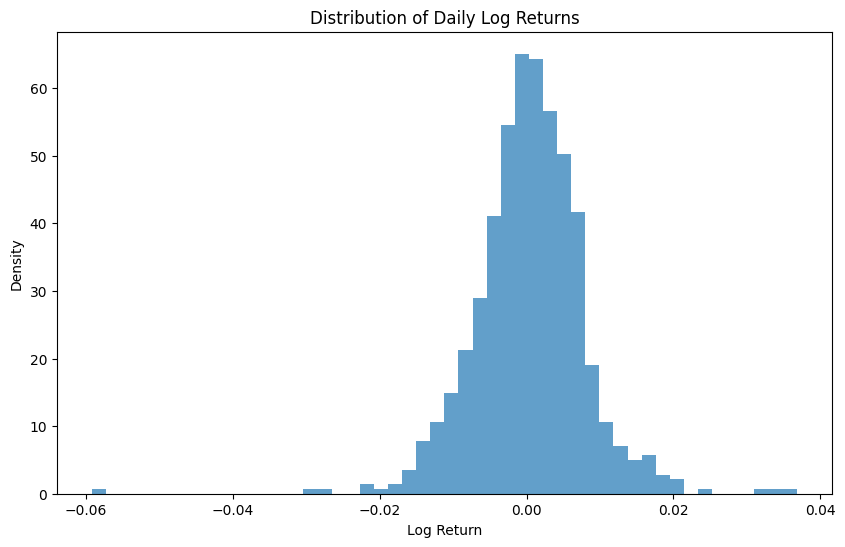

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(df['log_returns'],bins=50,density=True,alpha=0.7)
# bins shows the number of blocks we have divided the return into, using density changes the y-axis from number of days to probability
# alpha is used for transparency (AI suggested 0.7 so that we can compare with ideal normal distribution easily)
plt.title("Distribution of Daily Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.show()

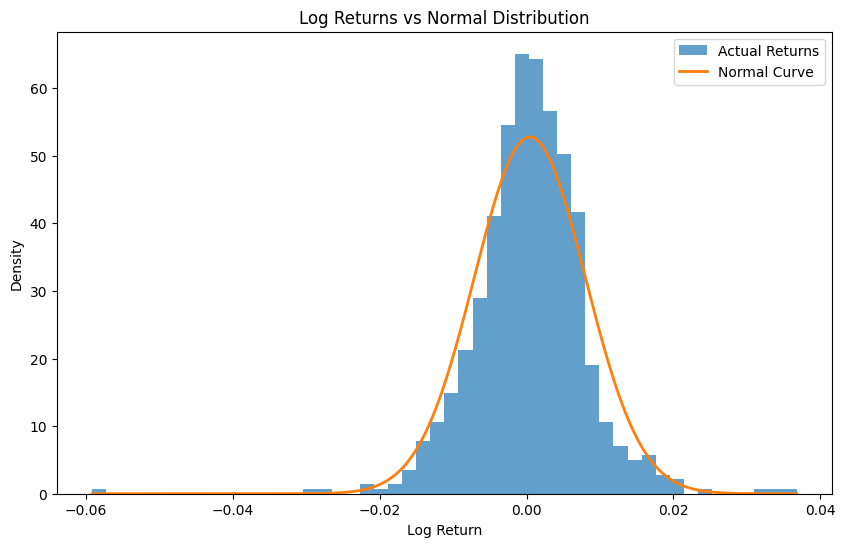

In [ ]:
# Comparing obtained plot with normal distribution
mu = df['log_returns'].mean()
sigma = df['log_returns'].std()

x = np.linspace(df['log_returns'].min(), df['log_returns'].max(),1000)
plt.figure(figsize=(10,6))
plt.hist(df['log_returns'],bins=50,density=True,alpha=0.7,label="Actual Returns")

plt.plot(x, stats.norm.pdf(x, mu, sigma),linewidth=2,label="Normal Curve")

plt.title("Log Returns vs Normal Distribution")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.show()

**OBSERVATION**: The log return is roughly like a bell-shaped curve but the tails are heavier than a normal distribution simply
because large gains occur more frequently than a normal model predicts and large losses also occur more frequently than a normal model predicts. Therefore, extreme events are more common than a gaussian assumption.

In [ ]:
returns = df['log_returns']

daily_mean = returns.mean()
annual_return = daily_mean * TRADING_DAYS
annual_volatility = returns.std() * np.sqrt(TRADING_DAYS)
annual_sharpe = annual_return / annual_volatility #Risk free rate= ZERO (else, we would have annual_return-risk_free_rate)
equity = np.exp(returns.cumsum())
peak = equity.cummax()
drawdown = (equity - peak) / peak
max_drawdown = drawdown.min()

print(f"Mean daily return  : {daily_mean*100:.4f}%")
print(f"Annualised return  : {annual_return*100:.2f}%")
print(f"Annualised vol     : {annual_volatility*100:.2f}%")
print(f"Sharpe ratio       : {annual_sharpe:.3f}")
print(f"Max drawdown       : {max_drawdown*100:.2f}%")
print(f"Best day           : {returns.max()*100:.2f}%")
print(f"Worst day          : {returns.min()*100:.2f}%")

Mean daily return  : 0.0450%
Annualised return  : 11.34%
Annualised vol     : 12.00%
Sharpe ratio       : 0.945
Max drawdown       : -14.97%
Best day           : 3.68%
Worst day          : -5.91%


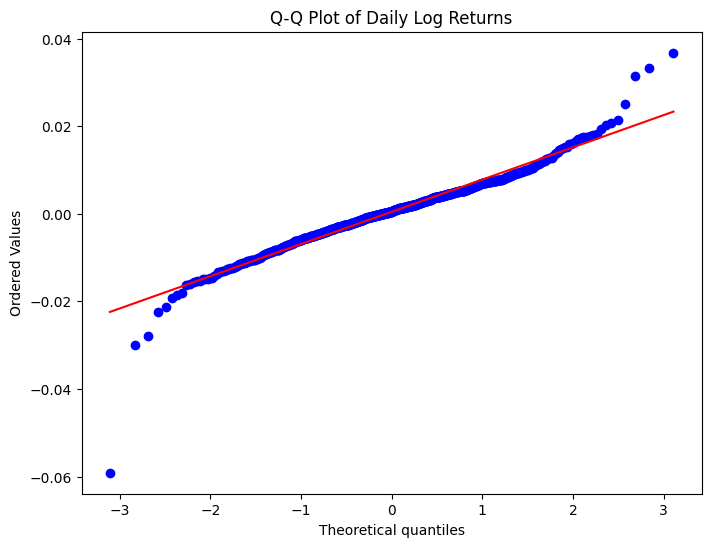

Excess Kurtosis: 6.827274112454029


In [ ]:
plt.figure(figsize=(8,6))

stats.probplot(returns, dist='norm', plot=plt)

plt.title("Q-Q Plot of Daily Log Returns")
plt.show()

print("Excess Kurtosis:", returns.kurtosis())

**Observation**: The Q-Q plot shows that the tails deviate from the straight reference line, indicating that the return distribution is not perfectly normal. The positive excess kurtosis confirms the presence of fat tails, which we observed in log returns v/s normal distribution plot, meaning extreme positive and negative returns occur more frequently than predicted by a Gaussian distribution.
The Sharpe Ratio, which relies mainly on mean and volatility, may underestimate tail risk.

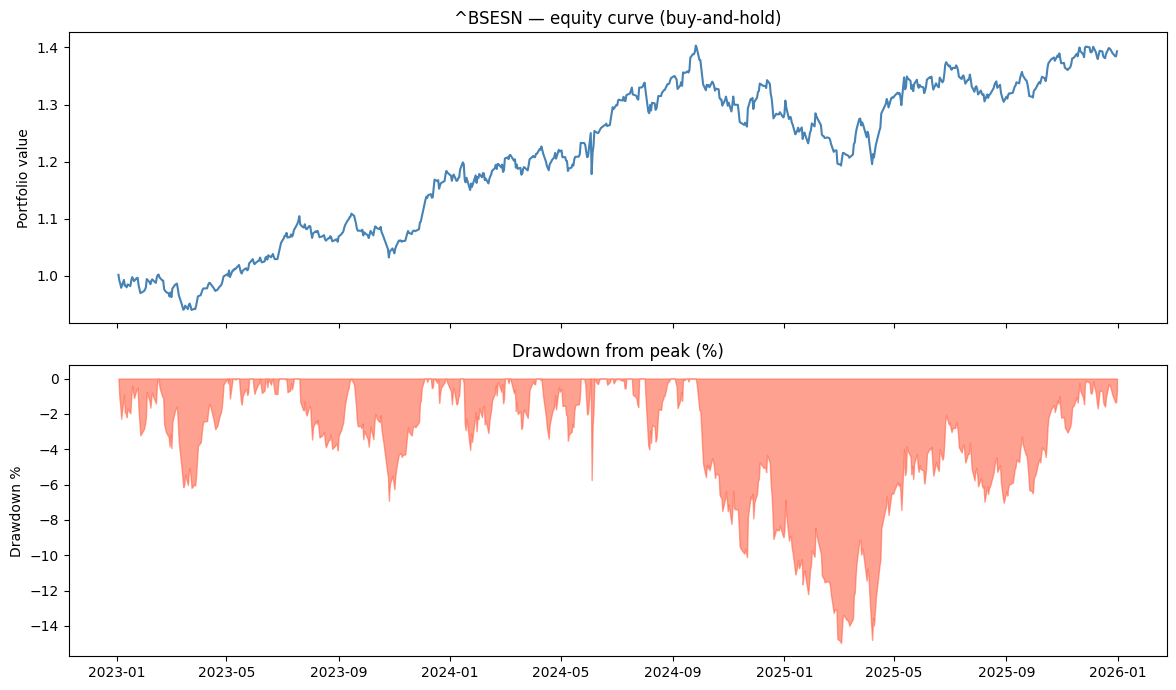

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(equity, color='steelblue')
ax1.set_title(f'{TICKER} — equity curve (buy-and-hold)')
ax1.set_ylabel('Portfolio value')
# Buy and hold shows what happens to equity (growth of 1 rupee invested at beginning) if we just hold and don't sell
ax2.fill_between(drawdown.index, drawdown * 100, 0, color='tomato', alpha=0.6)
ax2.set_title('Drawdown from peak (%)')
ax2.set_ylabel('Drawdown %')
# Drawdown shows how below are we from the previous all-time high.
plt.tight_layout()
plt.show()

The drawdown chart highlights periods where the portfolio fell below its previous peak. Larger drawdowns correspond to market corrections and provide a useful measure of downside risk beyond volatility alone.

# Working with our signal
**HYPOTHESIS**:
A 15-day moving average captures short-term market momentum, while a 75-day moving average represents the medium-term trend. The crossover between these averages is used to identify trend changes while reducing sensitivity to short-term market noise.

When the 15-day moving average of the Sensex rises above the 75-day moving average, I expect the Sensex to generate positive returns over the next several trading days, because the short-term trend is strengthening relative to the medium-term trend.

Recent buyers are typically holding positions with unrealised gains and are less likely to sell immediately, while trend-following investors may enter new positions, reducing selling pressure and reinforcing upward price momentum.

In [ ]:
df['moving_avg_short'] = df['close'].rolling(SHORT_WINDOW).mean()
df['moving_avg_long'] = df['close'].rolling(LONG_WINDOW).mean()

df['signal'] = (df['moving_avg_short']>df['moving_avg_long']).astype(int)
df['next_5days'] = df['log_returns'].rolling(5).sum().shift(-5)
# The shift(-5) moves that future return back to today's row because we are evaluating the signal, not trading with future information.

on = df[df['signal'] == 1]
off = df[df['signal'] == 0]

print(f"Signal ON for {len(on)} days ({len(on)/len(df)*100:.1f}%)")
print(f"Signal OFF for {len(off)} days ({len(off)/len(df)*100:.1f}%)")
# Checking how many days, 15-day average was greater and lower than the 75-day moving average.
print()
print(f"Average 5-day return when signal ON  :{on['next_5days'].mean()*100:.2f}%")
print(f"Average 5-day return when signal OFF :{off['next_5days'].mean()*100:.2f}%")
# Comparing future returns of next 5 days when the signal is off and when it is on

Signal ON for 468 days (63.5%)
Signal OFF for 269 days (36.5%)

Average 5-day return when signal ON  :0.29%
Average 5-day return when signal OFF :0.12%


**Inference**: The signal appears to have predictive power. When the 15-day moving average is above the 75-day moving average, the average 5-day forward return is 0.29%, compared with 0.12% when the signal is OFF. This supports the hypothesis that periods of stronger short-term momentum relative to the medium-term trend are associated with higher subsequent returns.

In [ ]:
# We have concluded that that the signal is predictive and hence, we now simulate the strategy
df['strategy_returns'] = df['log_returns'] * df['signal'].shift(1)
strategy = df['strategy_returns'].dropna()
#using .shift(1), because if 15-day moving average > 75-day moving average on Monday, then we can trade on Tuesday i.e. 1 day later.
#Basically, we are trying to avoid look-ahead bias.
strategy_annual_return = strategy.mean() * TRADING_DAYS
strategy_annual_volatility = strategy.std() * np.sqrt(TRADING_DAYS)
strategy_sharpe = strategy_annual_return / strategy_annual_volatility #Risk free rate= ZERO (else, we would have strategy_annual_return - risk_free_rate)
strategy_equity = np.exp(strategy.cumsum())
strategy_peak = strategy_equity.cummax()
strategy_max_drawdown = ((strategy_equity - strategy_peak) / strategy_peak).min()

print(f"Annualised return : {strategy_annual_return*100:.2f}%")
print(f"Annualised vol : {strategy_annual_volatility*100:.2f}%")
print(f"Sharpe ratio : {strategy_sharpe:.3f}")
print(f"Max drawdown : {strategy_max_drawdown*100:.2f}%")

Annualised return : 10.12%
Annualised vol : 9.44%
Sharpe ratio : 1.072
Max drawdown : -7.04%


In [ ]:
# Comparing the buy-and-hold (just keep the stock without doing anything) & the strategy returns
results = pd.DataFrame({'Buy-and-Hold': [annual_return*100, annual_volatility*100, annual_sharpe, max_drawdown*100],
                        'Signal':[strategy_annual_return*100, strategy_annual_volatility*100, strategy_sharpe, strategy_max_drawdown*100]},
                        index=['Annual Return (%)', 'Annual Volatility (%)', 'Sharpe', 'Max Drawdown (%)'])

print(results.round(3).to_string())

                       Buy-and-Hold  Signal
Annual Return (%)            11.339  10.124
Annual Volatility (%)        12.000   9.440
Sharpe                        0.945   1.072
Max Drawdown (%)            -14.966  -7.039


**Initial Thoughts on observing data:**
1. Return is slightly lower which means the moving-average filter occasionally keeps us out of the market during profitable periods.
2. Volatility reduces substantially. This suggests the signal successfully avoids some noisy market periods.
3. Increase in sharpe shows that we have got slightly less return with substantially less risk.
4. About 50% improvement in maximum drawdown shows a substantially better downside protection.

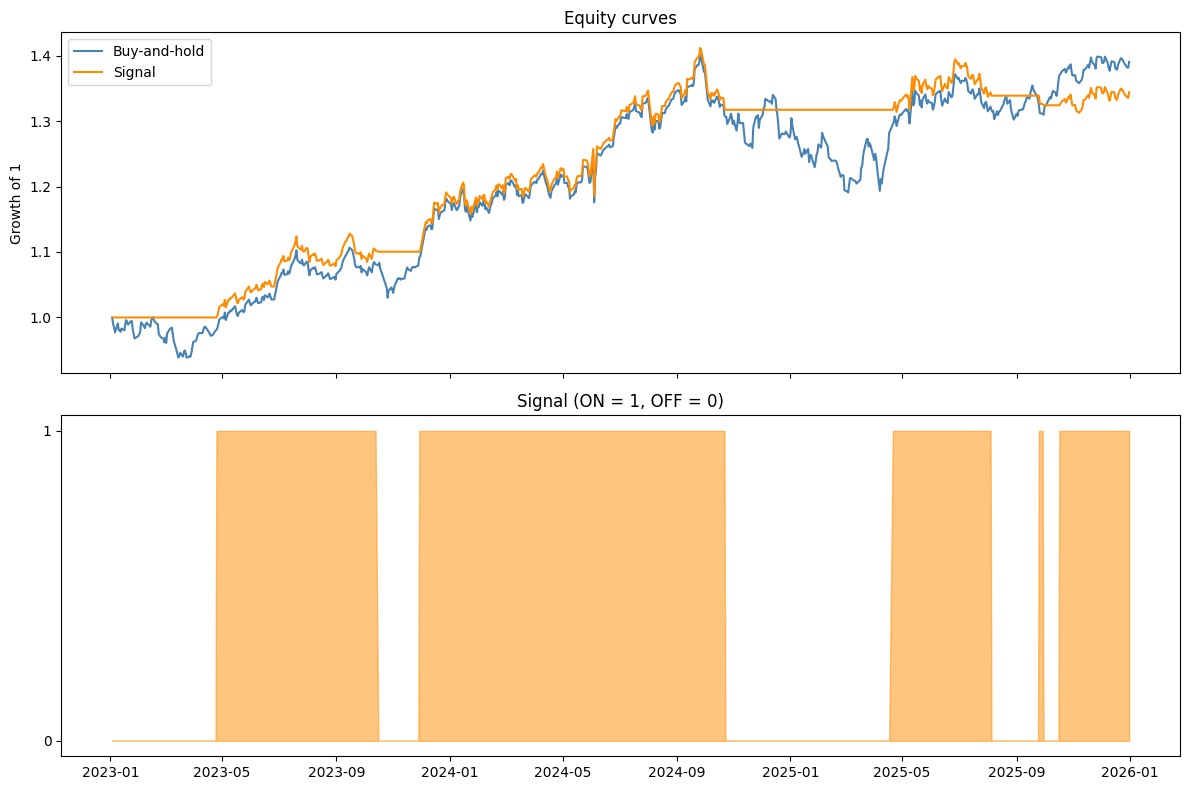

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
bh = equity / equity.iloc[0]
sg = strategy_equity / strategy_equity.iloc[0]

ax1.plot(bh, label='Buy-and-hold', color='steelblue')
ax1.plot(sg, label='Signal',       color='darkorange')
ax1.set_title('Equity curves')
ax1.set_ylabel('Growth of 1')
ax1.legend()

ax2.fill_between(df.index, df['signal'], 0, alpha=0.5, color='darkorange')
ax2.set_title('Signal (ON = 1, OFF = 0)')
ax2.set_yticks([0, 1])

plt.tight_layout()
plt.show()

**Observation:**

In the first graph, the orange line is often above the blue line in the equity curve. Large dip in blue curve in early 2025 is observed while orange curve becomes almost flat. So, the strategy avoided a significant portion of the decline.

The second graph shows the periods when we have invested (shaded periods) and the periods when we are in cash (blank periods).

# STRATEGY ASSESSMENT:

**(a) Risk in Live Trading**

The strategy that we have used depends a lot on the market having sustained trends. When prices consistently go upward or downward, the strategy works well.

However, if we have a market that **moves up and down frequently** without a clear trend, **the strategy keeps getting fooled by short lived moves because no real trend develops**. In such environments, the short-term moving average may repeatedly cross above and below the long-term moving average, generating false signals and causing the strategy to enter and exit positions frequently.

In [ ]:
# (b) Independent Observations
total_days = len(df)
longest_window = LONG_WINDOW
n_independent = total_days // longest_window
print(n_independent)

standard_error = 1 / np.sqrt(n_independent)
lower = strategy_sharpe - 1.96 * standard_error
upper = strategy_sharpe + 1.96 * standard_error

print(f"95% Confidence Interval: [{lower:.3f}, {upper:.3f}]")

9
95% Confidence Interval: [0.419, 1.726]


Although the estimated sharpe ratio was 1.072, the confidence interval is relatively wide because the moving-average signal is based on overlapping rolling windows, which reduces the number of truly independent observations. With only about 9 independent observations, the true sharpe could possibly be much lower (0.419) or much higher (1.726).

**(c) Result Assessment**

Sharpe in buy-and-hold case was 0.945 but increased to 1.072, when strategy was used.
More importantly, maximum drawdown was -14.966% in buy and hold case, which improved significantly to -7.039% when we used the signal.

Higher sharpe and smaller maximum drawdown shows that the strategy is a genuine improvement. The higher sharpe ratio indicates better risk-adjusted returns, while the lower drawdown shows that the strategy was able to avoid a significant portion of the market's worst declines.


# SUMMARY
| Metric              | Buy-and-Hold | Signal Strategy |
| ------------------- | -----------: | --------------: |
| Ann. Return (%)     |       11.339 |          10.124 |
| Ann. Volatility (%) |       12.000 |           9.440 |
| Sharpe Ratio        |        0.945 |           1.072 |
| Max Drawdown (%)    |      -14.966 |          -7.039 |


The signal was based on a 15-day and 75-day moving-average crossover, **a trend-following strategy** that attempts to stay invested during sustained uptrends and move out of the market during weaker periods.

The strategy produced a **higher sharpe ratio** (1.072 vs 0.945) and **substantially reduced maximum drawdown** (-7.039% vs -14.966%), indicating improved risk-adjusted performance despite a **slightly lower annual return**. This is consistent with the idea that momentum and trend-following signals can help avoid some market declines by responding to changes in price trends.

 However, the confidence interval on the sharpe ratio was relatively wide because the signal is based on overlapping rolling windows, meaning the **number of truly independent observations is much smaller** than the number of trading days. Therefore, the results are encouraging but should be interpreted cautiously and validated on additional data before being trusted in live trading.

                                             Sourish Srivastava (2025MT61515)